In [1]:
from pyCicero import preprocess
from pyCicero import run_cicero
from pyCicero import correlate_peaks

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.io import mmread

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*force_all_finite.*")

In [4]:
counts = mmread("../../05_2025_raw_data/ATAC/05_02_2025_neuronal_FMatrix.mtx").T.tocsr()

In [5]:
obs_names = pd.read_csv("../../05_2025_raw_data/ATAC/05_02_2025_neuronal_FMatrix_Col_Names.csv", index_col=0)
vars = pd.read_csv("../../05_2025_raw_data/ATAC/05_02_2025_neuronal_FMatrix_Row_Names.csv", index_col=0)
vars.index = ["merged-id" + str(x) for x in vars.index.values]
obs = pd.read_csv("../../05_2025_raw_data/ATAC/05_02_2025_Meta_Data.csv", index_col=0)
obs = obs.reindex(obs_names["x"])

In [6]:
counts.data[counts.data > 0] = 1
shuffle = False
if shuffle:
    rng = np.random.RandomState(0)
    counts = counts[:, rng.permutation(counts.shape[1])]

In [7]:
adata = sc.AnnData(counts, obs = obs, var = vars)

In [8]:
adata = adata[:,["chr" in x for x in vars["x"].values]] #subset adata to only have chromosomes that contain "chr" 

In [9]:
annotations_neuronal_atac = pd.read_csv("../../05_2025_Merged_ATAC_Neuronal_Homer_annotations.txt", sep = "\t") #from HOMER annotatePeaks.pl
annotated_vars = annotations_neuronal_atac.set_index(annotations_neuronal_atac.columns[0]).reindex(adata.var.index)

In [10]:
adata.var = annotated_vars
adata.var.insert(3, "Mean", (adata.var["Start"] + adata.var["End"])/2)

In [11]:
adata.var.head() #to run, you NEED columns ["Chr", "Start", "End"] in var. "Mean" is optional and will be calculated as the above cell if not in var. "Mean" will be used to calculate euclid distance between vars. 

,Chr,Start,End,Mean,Strand,Peak Score,Focus Ratio/Region Size,Annotation,Detailed Annotation,Distance to TSS,Nearest PromoterID,Entrez ID,Nearest Unigene,Nearest Refseq,Nearest Ensembl,Gene Name,Gene Alias,Gene Description,Gene Type
merged-id1,chr1,3012503,3013002,3012752.5,+,0,NaN,Intergenic,Intergenic,658746,NM_001011874,497097.0,NaN,NM_001011874,ENSMUSG00000051951,Xkr4,Gm210|XRG4|mKIAA1889,X-linked Kx blood group related 4,protein-coding
merged-id2,chr1,3027112,3027611,3027361.5,+,0,NaN,Intergenic,L1MEf|LINE|L1,644137,NM_001011874,497097.0,NaN,NM_001011874,ENSMUSG00000051951,Xkr4,Gm210|XRG4|mKIAA1889,X-linked Kx blood group related 4,protein-coding
merged-id3,chr1,3043908,3044407,3044157.5,+,0,NaN,Intergenic,Intergenic,627341,NM_001011874,497097.0,NaN,NM_001011874,ENSMUSG00000051951,Xkr4,Gm210|XRG4|mKIAA1889,X-linked Kx blood group related 4,protein-coding
merged-id4,chr1,3101044,3101543,3101293.5,+,0,NaN,Intergenic,Intergenic,570205,NM_001011874,497097.0,NaN,NM_001011874,ENSMUSG00000051951,Xkr4,Gm210|XRG4|mKIAA1889,X-linked Kx blood group related 4,protein-coding
merged-id5,chr1,3118613,3119112,3118862.5,+,0,NaN,Intergenic,RLTR20B4_MM|LTR|ERVK,552636,NM_001011874,497097.0,NaN,NM_001011874,ENSMUSG00000051951,Xkr4,Gm210|XRG4|mKIAA1889,X-linked Kx blood group related 4,protein-coding


In [12]:
adata = preprocess.preprocess_cicero(adata) #or device = "gpu" for RAPIDS UMAP 

2025-05-14 21:39:24.383709: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-14 21:39:24.408189: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-14 21:39:24.408209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-14 21:39:24.409719: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-14 21:39:24.414751: I tensorflow/core/platform/cpu_feature_gua

In [ ]:
# sc.pl.umap(adata) #check if UMAP is ok

In [13]:
cicero_adata = preprocess.make_cicero_adata(adata, k = 50)

preprocess.py: 2025-05-14 21:42:42 INFO     Using adata OBSM X_umap to agregate cells
preprocess.py: 2025-05-14 21:42:42 INFO     Calculating overlap
preprocess.py: 2025-05-14 21:42:42 INFO     Generating Pseudobulk cicero observations with seed: 0 and k: 50
preprocess.py: 2025-05-14 21:42:52 INFO     Reached Maximum itterations in pseudobulk observation generation. Consider increasing 'max_itterations'
preprocess.py: 2025-05-14 21:42:52 INFO     Found 3253 good choices
preprocess.py: 2025-05-14 21:42:52 INFO     Finished calculating overlap
preprocess.py: 2025-05-14 21:42:52 INFO     Aggregating Cells
preprocess.py: 2025-05-14 21:43:21 INFO     Finished Aggregating Cells


In [ ]:
cons = run_cicero.run_cicero(cicero_adata, quiet = False)

In [ ]:
cons[np.abs(cons["coaccess_score"]) > 0.2].head()

,Peak1,Peak2,coaccess_score
195,merged-id1000,merged-id1001,0.303800
268,merged-id1000,merged-id999,0.277292
479,merged-id100000,merged-id99999,0.550394
1085,merged-id100006,merged-id100007,0.201678
1236,merged-id100007,merged-id100041,0.230134


In [ ]:
import pickle
cons_shuffled = pickle.load(open("cons_shuffled.pickle", "rb"))

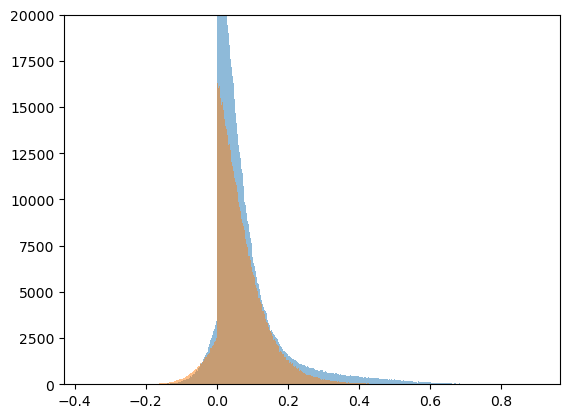

In [ ]:
import matplotlib.pyplot as plt
plt.hist(cons["coaccess_score"], bins = 500, label = "Non-Shuffled", alpha = 0.5)
plt.hist(cons_shuffled["coaccess_score"], bins = 500, label = "Shuffled", alpha = 0.5)
plt.ylim((0, 20000))
plt.show()

In [ ]:
rna_adata = sc.read_h5ad("../../../spinal_cord_main/03_2025_Objects/Figure 1/03_2025_main_adata.h5ad")
mapping_dict = pd.read_csv("../../translated_valid_neuronal_barcodes_atac.csv", index_col=0)["barcode"].to_dict()

In [ ]:
rna_adata = rna_adata[rna_adata.obs_names.isin(mapping_dict.keys())].raw.to_adata() #make sure the names of the ATAC and RNA are the same 
rna_adata.obs_names = list(map(mapping_dict.get, rna_adata.obs_names))
atac_adata = adata #use the original atac adata if not agregating

In [ ]:
cons_correlated = correlate_peaks.correlate_peaks(cons, rna_adata, atac_adata)

correlate_peaks.py: 2025-05-08 10:48:53 INFO     Generating Peak to Links
correlate_peaks.py: 2025-05-08 10:48:53 INFO     Finished generating Peak to Links
correlate_peaks.py: 2025-05-08 10:48:53 WARNING  rna and atac adata do not share the same obs_names. Trying to fix by computing union of cell names
correlate_peaks.py: 2025-05-08 10:48:53 WARNING  Subsetting to 96.88% of original observations
correlate_peaks.py: 2025-05-08 10:48:55 INFO     Runnign Correlation with pearson correlation
correlate_peaks.py: 2025-05-08 10:48:57 INFO     Finsihed running Correlation
correlate_peaks.py: 2025-05-08 10:48:57 INFO     Adding Links and Correlation to Cons
correlate_peaks.py: 2025-05-08 10:48:57 INFO     Finished


In [ ]:
cons_correlated.head(5)

,Peak1,Peak2,coaccess_score,Peak1_Proximal|Distal,Peak2_Proximal|Distal,Gene,RNA_Correlations
8690,merged-id100079,merged-id100152,0.224983,Proximal,Distal,Zbtb40,-0.011161
9325,merged-id100086,merged-id100127,0.211915,Distal,Proximal,Wnt4,0.051753
12124,merged-id100127,merged-id100128,0.479240,Proximal,Distal,Wnt4,0.051753
14629,merged-id100179,merged-id100219,0.205189,Distal,Proximal,Rap1gap,0.091376
17400,merged-id100207,merged-id100208,0.277766,Proximal,Distal,Rap1gap,0.064194


In [ ]:
#If you run with aggregation pass cicero_adata instead of atac_adata
#aggregation not recomended see aggregate_vs_non_aggregate.ipynb
cons_correlated_aggregate = correlate_peaks.correlate_peaks(cons, rna_adata, cicero_adata, aggregate = True)

correlate_peaks.py: 2025-05-08 10:49:09 INFO     Aggregating rna_adata to match cicero_adata
correlate_peaks.py: 2025-05-08 10:49:12 INFO     Finished Aggregation
correlate_peaks.py: 2025-05-08 10:49:12 INFO     Generating Peak to Links
correlate_peaks.py: 2025-05-08 10:49:12 INFO     Finished generating Peak to Links
correlate_peaks.py: 2025-05-08 10:49:14 INFO     Runnign Correlation with pearson correlation
correlate_peaks.py: 2025-05-08 10:49:15 INFO     Finsihed running Correlation
correlate_peaks.py: 2025-05-08 10:49:15 INFO     Adding Links and Correlation to Cons
correlate_peaks.py: 2025-05-08 10:49:15 INFO     Finished


In [ ]:
print(f"Mean Abs Correlation without Aggregation: {np.mean(np.abs(cons_correlated['RNA_Correlations'])):.4f}")
print(f"Mean Abs Correlation With Aggregation: {np.mean(np.abs(cons_correlated_aggregate['RNA_Correlations'])):.4f}")

Mean Abs Correlation without Aggregation: 0.0454
Mean Abs Correlation With Aggregation: 0.3122
